In [1]:
from pathlib import Path


def data_dir() -> Path:
    """หาโฟลเดอร์ datasets/ โดยไล่ขึ้นจาก cwd."""
    for p in (Path.cwd(), *Path.cwd().parents):
        if (p / "datasets").exists():
            return p / "datasets"
    raise SystemExit(
        "ไม่พบโฟลเดอร์ datasets/ — เปิด JupyterLab จาก repo root (uv run "
        "jupyter lab)"
    )


DATA = data_dir()


# Module 1 — ML Workflow & Exploratory Data Analysis (EDA)

**Dataset ที่ใช้ในโมดูลนี้ (โปรดอ่านก่อนใช้งาน):**

- *Air Quality* — De Vito, S., Massera, E., Piga, M., Martinotto, L., Di Francia, G. (2008). UCI Machine Learning Repository. https://doi.org/10.24432/C59K5F (CC BY 4.0). ข้อมูลจริงจากเครื่องตรวจวัดแก๊สชนิด metal-oxide multisensor ที่ติดตั้งกลางแจ้งในอิตาลี วัดรายชั่วโมง 9,358 แถว พร้อมเครื่องอ้างอิง (reference analyzer) และเซนเซอร์ T/RH
- *Combined Cycle Power Plant* — Tüfekci, P. & Kaya, H. (2014). UCI Machine Learning Repository. https://doi.org/10.24432/C5002N (CC BY 4.0)

ไฟล์อยู่ที่ `datasets/air_quality_uci.csv` และ `datasets/ccpp_power_plant.csv` — เปิด JupyterLab จาก repo root เสมอ

## 1. วงจรงาน Machine Learning ที่ใช้กันจริง

โปรเจกต์ ML ที่สำเร็จไม่ได้เริ่มจาก "เลือกโมเดลอะไรดี" แต่เริ่มจากคำถามที่ชัด:

```text
1. ตั้งคำถาม     →  อยากรู้อะไร ใครใช้ผล ผิดพลาดแล้วเสียหายเท่าไร
2. ได้ข้อมูล      →  มาจากไหน หน่วยอะไร ใครวัด ด้วยเครื่องอะไร มาตรฐานใด
3. สำรวจ (EDA)   →  รู้จักข้อมูลก่อนฝากให้โมเดล
4. เตรียม feature →  โมดูลถัดไป
5. เทรนโมเดล     →  เริ่มจากโมเดลง่ายที่สุดเสมอ
6. ประเมิน       →  แยกข้อมูลทดสอบออกก่อน ไม่โกงตัวเอง
7. ทำซ้ำ         →  ผลประเมินบอกให้กลับไปขั้น 3–5
```

สำหรับงานเมโทรโลยี ขั้น 1–2 สำคัญเป็นพิเศษ: เราต้องรู้ **traceability** ของข้อมูล — ช่องสัญญาณนี้มาจากเซนเซอร์ตัวไหน ถูกสอบเทียบกับ standard ตัวไหน หน่วยเป็นอะไร ข้อมูลหลายชุดในงานจริงพังจากการเข้าใจหน่วย/ช่วงสอบเทียบผิด มากกว่าจากโมเดลไม่ดี

## 2. โหลดข้อมูลด้วย polars — ไลบรารีตารางหลักของหลักสูตร

Air Quality: คั่นด้วย ';' และค่าที่เซนเซอร์/analyzer พังถูกแท็กเป็น -200 → บอก polars ให้แปลง -200 เป็น null ตั้งแต่ตอนอ่าน (ข้อมูลสะอาดตั้งแต่ประตู)

In [2]:
import polars as pl  # noqa: E402

aq = pl.read_csv(
    DATA / "air_quality_uci.csv",
    separator=";",
    null_values="-200",
)
print(aq.shape)
aq.head(3)


(9471, 17)


Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,,_duplicated_0
str,str,str,i64,i64,str,i64,i64,i64,i64,i64,i64,str,str,str,str,str
"""10/03/2004""","""18.00.00""","""2,6""",1360,150,"""11,9""",1046,166,1056,113,1692,1268,"""13,6""","""48,9""","""0,7578""",null,null
"""10/03/2004""","""19.00.00""","""2""",1292,112,"""9,4""",955,103,1174,92,1559,972,"""13,3""","""47,7""","""0,7255""",null,null
"""10/03/2004""","""20.00.00""","""2,2""",1402,88,"""9,0""",939,131,1140,114,1555,1074,"""11,9""","""54,0""","""0,7502""",null,null


**สังเกต 2 อย่าง:**
1. ไฟล์จริงมักไม่สะอาด — ไฟล์นี้คั่นด้วย `;` และทศนิยมเป็น **comma** (ยุโรป) ซึ่ง polars แปลงคอลัมน์ตัวเลขที่มี comma เป็น string ให้เอง แล้วเราจะแปลงต่อข้างล่าง
2. `Date`, `Time` เป็นข้อความ — ต้องรวมเป็น datetime จริงก่อนใช้วิเคราะห์เชิงเวลา

แปลงคอลัมน์ทศนิยมแบบ comma ("2,6") เป็น float จริง (ค่าแท็ก -200 ที่หลุดมาในคอลัมน์ string ถูกเปลี่ยนเป็น null ด้วย)

In [3]:
decimal_cols = [
    c
    for c, dtype in aq.schema.items()
    if dtype == pl.String and c not in ("Date", "Time")
]
aq = aq.with_columns(
    [
        pl.col(c)
        .str.replace(",", ".", literal=True)
        .cast(pl.Float64)
        .replace(-200.0, None)
        for c in decimal_cols
    ]
)
aq.schema


Schema([('Date', String),
        ('Time', String),
        ('CO(GT)', Float64),
        ('PT08.S1(CO)', Int64),
        ('NMHC(GT)', Int64),
        ('C6H6(GT)', Float64),
        ('PT08.S2(NMHC)', Int64),
        ('NOx(GT)', Int64),
        ('PT08.S3(NOx)', Int64),
        ('NO2(GT)', Int64),
        ('PT08.S4(NO2)', Int64),
        ('PT08.S5(O3)', Int64),
        ('T', Float64),
        ('RH', Float64),
        ('AH', Float64),
        ('', Float64),
        ('_duplicated_0', Float64)])

รวม Date + Time เป็น timestamp จริง (รูปแบบ: 10/03/2004 และ 18.00.00)

In [4]:
aq = aq.with_columns(
    pl.format("{} {}", pl.col("Date"), pl.col("Time"))
    .str.strptime(pl.Datetime, format="%d/%m/%Y %H.%M.%S", strict=False)
    .alias("ts")
)
aq.select("ts", "CO(GT)", "T", "RH").head(3)


ts,CO(GT),T,RH
datetime[μs],f64,f64,f64
2004-03-10 18:00:00,2.6,13.6,48.9
2004-03-10 19:00:00,2.0,13.3,47.7
2004-03-10 20:00:00,2.2,11.9,54.0


## 3. ตรวจภาพรวมก่อนเชื่อใคร

กฎเหล็ก: **อย่าเชื่อคำบรรยายข้อมูล ให้เชื่อสิ่งที่ print ออกมา**

ชนิดข้อมูลแต่ละคอลัมน์ + สถิติพื้นฐาน

In [5]:
aq.select(pl.exclude("Date", "Time")).describe()


statistic,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,,_duplicated_0,ts
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str
"""count""",7674.0,8991.0,914.0,8991.0,8991.0,7718.0,8991.0,7715.0,8991.0,8991.0,8991.0,8991.0,8991.0,0.0,0.0,"""9357"""
"""null_count""",1797.0,480.0,8557.0,480.0,480.0,1753.0,480.0,1756.0,480.0,480.0,480.0,480.0,480.0,9471.0,9471.0,"""114"""
"""mean""",2.15275,1099.833166,218.811816,10.083105,939.153376,246.896735,835.493605,113.091251,1456.264598,1022.906128,18.317829,49.234201,1.02553,null,null,"""2004-09-21 16:00:00"""
"""std""",1.453252,217.080037,204.459921,7.44982,266.831429,212.979168,256.81732,48.370108,346.206794,398.484288,8.832116,17.316892,0.403813,null,null,null
"""min""",0.1,647.0,7.0,0.1,383.0,2.0,322.0,2.0,551.0,221.0,-1.9,9.2,0.1847,null,null,"""2004-03-10 18:00:00"""
"""25%""",1.1,937.0,67.0,4.4,735.0,98.0,658.0,78.0,1227.0,732.0,11.8,35.8,0.7369,null,null,"""2004-06-16 05:00:00"""
"""50%""",1.8,1063.0,150.0,8.2,909.0,180.0,806.0,109.0,1463.0,963.0,17.8,49.6,0.9954,null,null,"""2004-09-21 16:00:00"""
"""75%""",2.9,1231.0,297.0,14.0,1116.0,326.0,970.0,142.0,1674.0,1274.0,24.4,62.5,1.3138,null,null,"""2004-12-28 03:00:00"""
"""max""",11.9,2040.0,1189.0,63.7,2214.0,1479.0,2683.0,340.0,2775.0,2523.0,44.6,88.7,2.231,null,null,"""2005-04-04 14:00:00"""


จำนวนค่าหายต่อคอลัมน์ — จัดอันดับดูว่าคอลัมน์ไหนเสียหนัก

In [6]:
nulls = aq.null_count().transpose(
    include_header=True, header_name="column", column_names=["n_null"]
)
nulls = nulls.with_columns(
    (pl.col("n_null") / aq.height * 100).round(2).alias("pct")
)
nulls.sort("pct", descending=True)


column,n_null,pct
str,u32,f64
"""""",9471,100.0
"""_duplicated_0""",9471,100.0
"""NMHC(GT)""",8557,90.35
"""CO(GT)""",1797,18.97
"""NO2(GT)""",1756,18.54
…,…,…
"""RH""",480,5.07
"""AH""",480,5.07
"""Date""",114,1.2


**อ่านผล:** `NMHC(GT)` หาย ~90% — ใช้งานจริงไม่ได้ ควรตัดทิ้งตอนเตรียมข้อมูล คอลัมน์ `CO(GT)`, `NOx(GT)`, `NO2(GT)` คือค่าจาก *เครื่องอ้างอิง* (GT = ground truth) หายราว 18% ส่วนช่องสัญญาณเซนเซอร์ `PT08.*` หายน้อยมาก

ประเด็นสำคัญเชิงเมโทรโลยี: คอลัมน์ "GT" คือค่าจาก **เครื่องสอบเทียบอ้างอิง** ส่วน `PT08.*` คือ **เซนเซอร์ที่เราอยากสอบเทียบให้เข้าใกล้ค่าอ้างอิง** — โจทย์ ML คลาสสิกของงานวัด: "ทำให้เซนเซอร์ถูกแพงสอบเทียบตัวเองด้วยผลจากเครื่องอ้างอิง"

## 4. EDA ทางเดียว: ดูการกระจายของแต่ละคอลัมน์

ฟอนต์ไทยสำหรับป้ายกราฟ — fallback list รองรับทุกแพลตฟอร์ม (macOS/Windows)

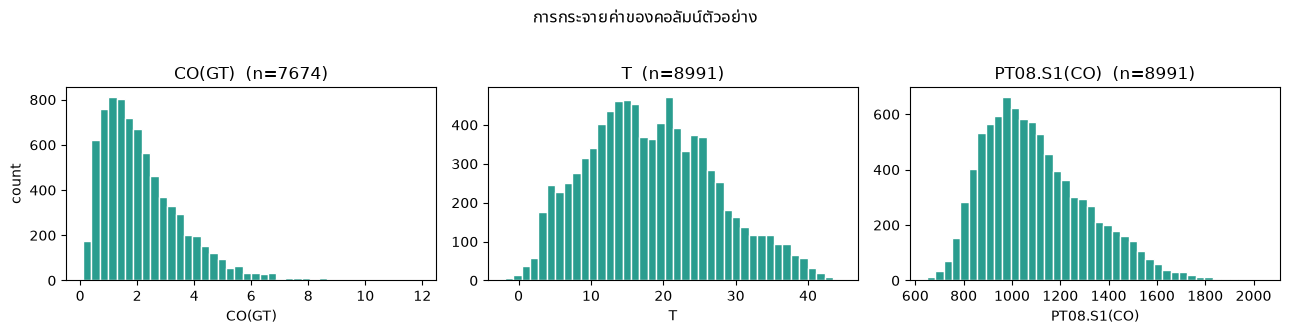

In [7]:
import matplotlib.pyplot as plt  # noqa: E402

plt.rcParams["font.family"] = [
    "DejaVu Sans",
    "Noto Sans Thai",
    "Leelawadee UI",
    "Tahoma",
    "Thonburi",
]

fig, axes = plt.subplots(1, 3, figsize=(13, 3.2))
for ax, col in zip(axes, ["CO(GT)", "T", "PT08.S1(CO)"]):
    x = aq[col].drop_nulls()
    ax.hist(x, bins=40, color="#2a9d8f", edgecolor="white")
    ax.set_title(f"{col}  (n={len(x)})")
    ax.set_xlabel(col)
axes[0].set_ylabel("count")
fig.suptitle("การกระจายค่าของคอลัมน์ตัวอย่าง", y=1.03)
fig.tight_layout()
plt.show()


**อ่านฮิสโตแกรม:** รูปทรงบอกเรื่องสำคัญ — สมมาตรรอบค่ากลาง (เหมือน normal) หรือเบ้ (มี tail ยาว) มี spike ที่ 0 (อาจเป็นค่าแทนค่าหายที่รั่วมา) หรือมีค่าสุดขั้วแปลก ๆ ที่ควรไปตรวจย้อน

boxplot เทียบหลายช่องสัญญาณในหน่วยเดียวกัน — หา outlier และเทียบความลื่น

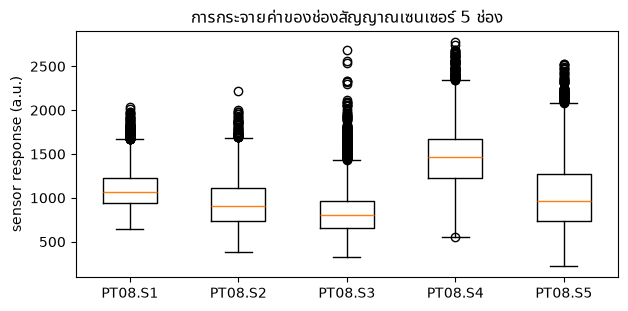

In [8]:
sensors = [
    "PT08.S1(CO)",
    "PT08.S2(NMHC)",
    "PT08.S3(NOx)",
    "PT08.S4(NO2)",
    "PT08.S5(O3)",
]
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.boxplot(
    [aq[c].drop_nulls() for c in sensors],
    tick_labels=[c.split("(")[0] for c in sensors],
)
ax.set_ylabel("sensor response (a.u.)")
ax.set_title("การกระจายค่าของช่องสัญญาณเซนเซอร์ 5 ช่อง")
plt.show()


## 5. EDA สองทาง: ความสัมพันธ์ระหว่างคอลัมน์

scatter: ช่องสัญญาณเซนเซอร์ vs ค่าอ้างอิง — ความสัมพันธ์เชิงเส้นหรือไม่

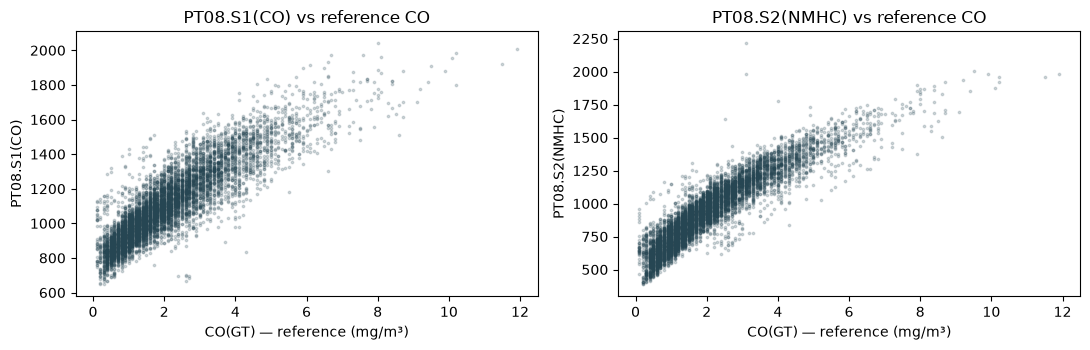

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), sharex=True)
for ax, col in zip(axes, ["PT08.S1(CO)", "PT08.S2(NMHC)"]):
    pair = aq.select(col, pl.col("CO(GT)").alias("co_gt")).drop_nulls()
    ax.scatter(pair["co_gt"], pair[col], s=3, alpha=0.2, color="#264653")
    ax.set_xlabel("CO(GT) — reference (mg/m³)")
    ax.set_ylabel(col)
    ax.set_title(f"{col} vs reference CO")
fig.tight_layout()
plt.show()


ความสัมพันธ์ชัด แต่ **ไม่เชิงเส้นสมบูรณ์** — รูปทรงโค้งเล็กน้อยและกระจายตัวมากขึ้นเมื่อค่า CO สูง (heteroscedastic) นี่คือข้อมูลเชิงลึกที่ EDA ให้ก่อนสร้างโมเดล: ถ้าโมเดลเชิงเส้นพื้นฐานไม่พอ อาจต้องใช้ polynomial feature (โมดูล 2) หรือโมเดลต้นไม้ (วันที่ 2)

correlation matrix ของคอลัมน์ตัวเลขทั้งหมด

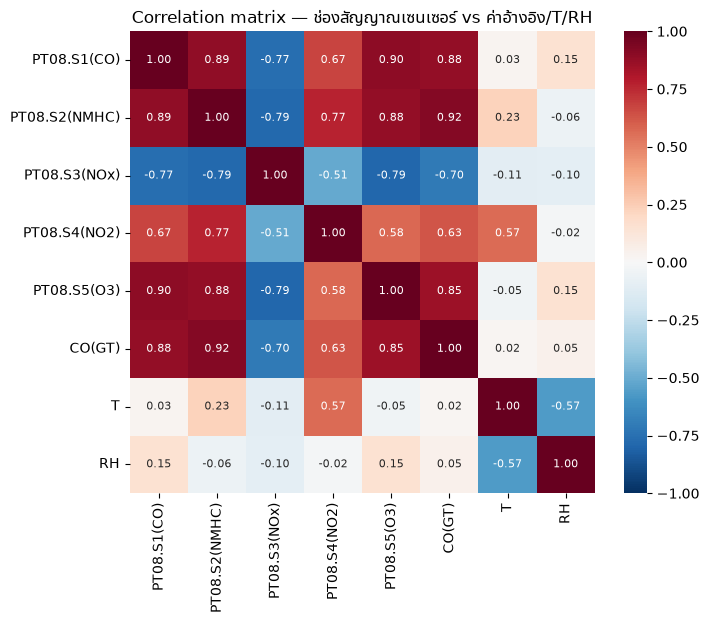

In [10]:
import seaborn as sns  # noqa: E402

cols = sensors + ["CO(GT)", "T", "RH"]
corr = aq.select(cols).drop_nulls().corr()
corr_pd = corr.to_pandas()
corr_pd.index = corr_pd.columns = cols

fig, ax = plt.subplots(figsize=(7.5, 6))
sns.heatmap(
    corr_pd,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
    ax=ax,
    annot_kws={"size": 8},
)
ax.set_title("Correlation matrix — ช่องสัญญาณเซนเซอร์ vs ค่าอ้างอิง/T/RH")
plt.show()


**อ่าน heatmap:** เซนเซอร์ `PT08.S1/S2/S4/S5` สัมพันธ์บวกกับ CO อ้างอิง ส่วน `PT08.S3` สัมพันธ์ **ลบ** (เซนเซอร์ตัวนี้ตอบสนอง NOx ซึ่งแย่งชิงกับ CO) — T และ RH กัดเซนเซอร์เกือบทุกตัว (cross-sensitivity ต่อสิ่งแวดล้อม) ซึ่งเป็นเหตุผลว่าทำไมงานสอบเทียบเซนเซอร์จริงต้องพิจารณา T/RH ควบคู่เสมอ

## 6. มิติเวลา — ข้อมูลเซนเซอร์มักไม่ใช่ "กลุ่มตัวอย่างอิสระ"

แนวโน้มรายวันของ CO อ้างอิง + ช่องสัญญาณเซนเซอร์ ช่วงเดือนแรก

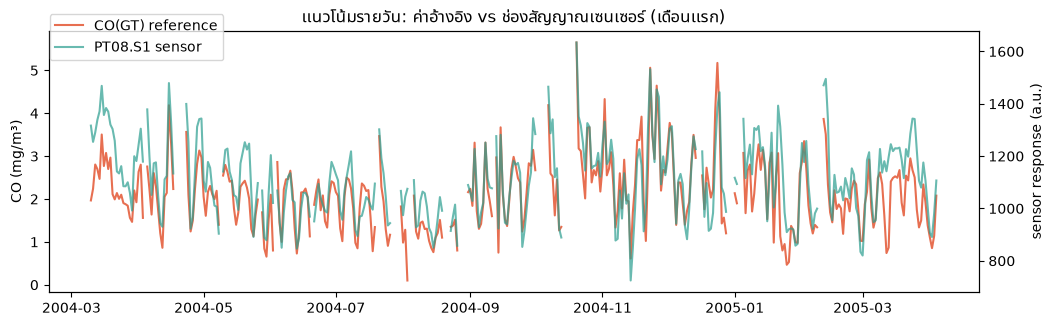

In [11]:

ts = (
    aq.select("ts", "CO(GT)", "PT08.S1(CO)")
    .drop_nulls()
    .to_pandas()
    .set_index("ts")
)
daily = ts.resample("1D").mean()

fig, ax1 = plt.subplots(figsize=(12, 3.4))
ax1.plot(
    daily.index, daily["CO(GT)"], color="#e76f51", label="CO(GT) reference"
)
ax1.set_ylabel("CO (mg/m³)")
ax2 = ax1.twinx()
ax2.plot(
    daily.index,
    daily["PT08.S1(CO)"],
    color="#2a9d8f",
    alpha=0.7,
    label="PT08.S1 sensor",
)
ax2.set_ylabel("sensor response (a.u.)")
ax1.set_title("แนวโน้มรายวัน: ค่าอ้างอิง vs ช่องสัญญาณเซนเซอร์ (เดือนแรก)")
fig.legend(loc="upper left", bbox_to_anchor=(0.12, 0.95))
plt.show()


เห็นแล้วว่าสองเส้นเดินตามกัน — แต่มีช่วงที่เซนเซอร์ขาด (ช่องว่างจากค่า null) และมีรูปแบบวนซ้ำรายสัปดาห์/รายวัน ข้อมูลเชิงเวลามีข้อควรระวังใหญ่: **แถวไม่ใช่กลุ่มตัวอย่างอิสระ** และการแบ่ง train/test แบบสุ่มจะรั่วข้อมูลอนาคต (เราจะเจอรูปธรรมเรื่องนี้ในวันที่ 3 เรื่อง time series)

## 7. ตัวอย่างที่สะอาดกว่า: CCPP — สำหรับฝึกตั้งคำถาม ML

ข้อมูลโรงไฟฟ้า 9,568 จุด: 4 ตัวแปรสิ่งแวดล้อม (อุณหภูมิ, สุญญากาศ, ความดัน, ความชื้น) → กำลังไฟฟ้าสุทธิ `PE` เราใช้ตั้งคำถามเชิง ML ตัวแรก: *"เดากำลังไฟฟ้าจากสภาพแวดล้อมได้แม่นแค่ไหน?"*

In [12]:
ccpp = pl.read_csv(DATA / "ccpp_power_plant.csv")
print(ccpp.shape)
ccpp.describe()


(9568, 5)


statistic,AT,V,AP,RH,PE
str,f64,f64,f64,f64,f64
"""count""",9568.0,9568.0,9568.0,9568.0,9568.0
"""null_count""",0.0,0.0,0.0,0.0,0.0
"""mean""",19.651231,54.305804,1013.259078,73.308978,454.365009
"""std""",7.452473,12.707893,5.938784,14.600269,17.066995
"""min""",1.81,25.36,992.89,25.56,420.26
"""25%""",13.51,41.74,1009.1,63.33,439.75
"""50%""",20.35,52.08,1012.94,74.98,451.58
"""75%""",25.72,66.54,1017.26,84.83,468.43
"""max""",37.11,81.56,1033.3,100.16,495.76


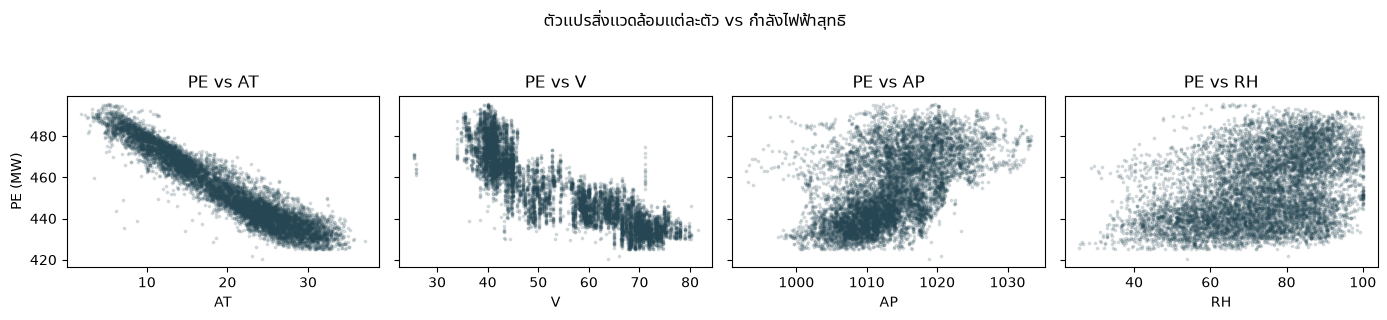

In [13]:
fig, axes = plt.subplots(1, 4, figsize=(14, 3.0), sharey=True)
for ax, col in zip(axes, ["AT", "V", "AP", "RH"]):
    ax.scatter(ccpp[col], ccpp["PE"], s=3, alpha=0.15, color="#264653")
    ax.set_xlabel(col)
    ax.set_title(f"PE vs {col}")
axes[0].set_ylabel("PE (MW)")
fig.suptitle("ตัวแปรสิ่งแวดล้อมแต่ละตัว vs กำลังไฟฟ้าสุทธิ", y=1.05)
fig.tight_layout()
plt.show()


`AT` (อุณหภูมิ) สัมพันธ์ทรงพลังที่สุดและเกือบเชิงเส้น — คำตอบเบื้องต้นของ EDA: "อุณหภูมิบอกกำลังไฟฟ้าได้มาก แต่ยังมีเศษกระจายเหลืออยู่" ซึ่งพาเราไปสู่โมดูลถัดไปโดยธรรมชาติ

## 8. กฎข้อแรกของ ML: แยก test set ก่อนจับต้องข้อมูล

ก่อนสร้างโมเดลใด ๆ เราแบ่งข้อมูลสองส่วน:
- **train set** — ให้โมเดลเรียนรู้
- **test set** — ล็อกไว้ในตู้เซฟ เปิดครั้งเดียวตอนประเมินครั้งสุดท้าย

เหตุผล: ถ้าเราปรับโมเดลโดยดูคำตอบใน test บ่อย ๆ เราจะได้ตัวเลขสวยแต่โกหก — เหมือนการสอบเทียบเครื่องมือด้วยมาตรฐานตัวเดียวกับที่จะเอาไปตรวจ แล้วอวดว่าแม่น

In [14]:
from sklearn.model_selection import train_test_split  # noqa: E402

X = ccpp.select("AT", "V", "AP", "RH")
y = ccpp["PE"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(
    f"train: {len(X_train)} rows | test: {
        len(X_test)
    } rows (เก็บ test ไว้ — ยังไม่แตะ!)"
)


train: 7654 rows | test: 1914 rows (เก็บ test ไว้ — ยังไม่แตะ!)


**แนวปฏิบัติที่เราจะทำตลอดหลักสูตร:** สุ่มด้วย `random_state=42` เสมอ เพื่อให้ทุกคนได้ split ชุดเดียวกัน — reproducibility อีกครั้ง

## 9. pandas ครั้งเดียวของหลักสูตร — interop

โลกจริงมีโค้ด pandas อยู่เต็มไปหมด หลักสูตรใช้ polars เป็นหลัก แต่คุณต้องแปลงข้ามไปมาได้:

- `df.to_pandas()` → pandas DataFrame (เช่น ให้ seaborn ใช้)
- `pl.from_pandas(pdf)` → กลับมาเป็น polars

In [15]:
pdf = aq.select("T", "RH", "CO(GT)").to_pandas()
print(type(pdf), pdf.dtypes.tolist())
back = pl.from_pandas(pdf)
print(type(back), back.shape)


<class 'pandas.DataFrame'> [dtype('float64'), dtype('float64'), dtype('float64')]
<class 'polars.dataframe.frame.DataFrame'> (9471, 3)


## สรุป EDA checklist — ทำครบก่อนสร้างโมเดลทุกครั้ง

1. รู้ที่มาและหน่วยของทุกคอลัมน์ (traceability)
2. ตรวจ schema/ชนิดข้อมูล — ตัวเลขจริงหรือ string ปลอมตัว
3. นับ missing ต่อคอลัมน์ แล้วตัดสินใจ: ตัดคอลัมน์ / เติมค่า (โมดูล 2)
4. ฮิสโตแกรม/boxplot ต่อคอลัมน์ — รูปทรง, outlier, ค่าแปลก
5. scatter/Correlation กับตัวแปรเป้าหมาย — feature ไหนน่าสนใจ
6. ถ้าข้อมูลมีเวลา: พล็อตตามเวลา แล้วคิดว่า train/test ควรแบ่งตามเวลาหรือสุ่ม
7. แยก test set ก่อนแตะอย่างอื่น